# Estimation for Joint Recovery of $p$ and $\theta$

We aim to jointly estimate the initial-condition parameters $p$ and the dynamic parameters $\theta = (\phi, \gamma)$ using only the final observation $h(T,x)$. The forward model is governed by the PDE

$$
\frac{\partial h(t,x)}{\partial t}
= C_0\, g(\phi; t)\, \frac{\partial}{\partial x}\big( u(\gamma; t, x)\, h(t,x)\big),
$$

with the initial condition represented by a Gaussian mixture

$$
h(0,x) = f(p).
$$

The inverse problem is formulated as the minimization of the regularized objective functional

$$
J(p,\theta)
=
\frac{1}{2}\,\|\,y - \mathcal{F}(p,\theta)\,\|_{W}^2
\;+\;
\lambda_p\, R_p(p)
\;+\;
\lambda_{\theta}\, R_{\theta}(\theta),
$$

where $y$ is the observed final state, $\mathcal{F}(p,\theta)$ is the forward PDE solution at $t=T$, and $R_p$, $R_\theta$ are regularization terms.

### Iniciar Ray 
```bash
ray start --head --dashboard-host=0.0.0.0 --node-ip-address=0.0.0.0
```



In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-02-27 11:14:11,886	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


Parâmetros ajustados:
phi_* = 1.891638463506376e-05
M_*   = 344105772.54815775
gamma1 = 0.19987137110713896
gamma2 = 2.5853015671226736


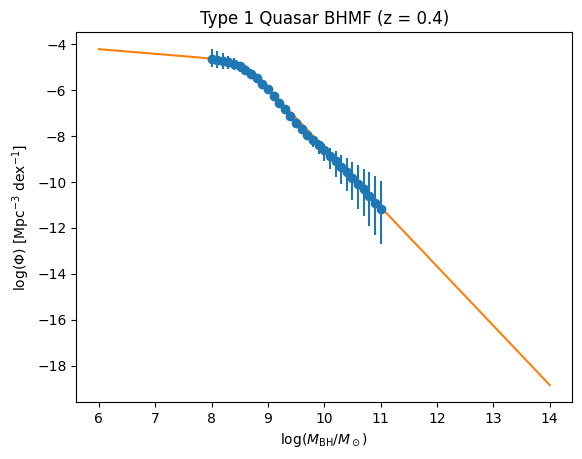

In [4]:


# Dados
log_MBH = np.array([
    8.000, 8.100, 8.200, 8.300, 8.400, 8.500, 8.600, 8.700,
    8.800, 8.900, 9.000, 9.100, 9.200, 9.300, 9.400, 9.500,
    9.600, 9.700, 9.800, 9.900, 10.000, 10.100, 10.200, 10.300,
    10.400, 10.500, 10.600, 10.700, 10.800, 10.900, 11.000
])

log_phi_lower = np.array([
    -5.00, -5.03, -5.06, -5.09, -5.14, -5.22, -5.32, -5.47,
    -5.65, -5.87, -6.12, -6.40, -6.70, -7.02, -7.32, -7.61,
    -7.89, -8.17, -8.48, -8.79, -9.10, -9.44, -9.79, -10.10,
    -10.40, -10.80, -11.20, -11.50, -11.90, -12.30, -12.70
])

log_phi_median = np.array([
    -4.64, -4.67, -4.72, -4.78, -4.87, -4.97, -5.12, -5.29,
    -5.49, -5.72, -5.97, -6.25, -6.54, -6.84, -7.14, -7.43,
    -7.70, -7.96, -8.19, -8.41, -8.63, -8.85, -9.09, -9.33,
    -9.57, -9.83, -10.10, -10.30, -10.60, -10.90, -11.20
])

log_phi_upper = np.array([
    -4.21, -4.30, -4.39, -4.50, -4.62, -4.76, -4.92, -5.09,
    -5.31, -5.54, -5.80, -6.08, -6.37, -6.67, -6.96, -7.25,
    -7.52, -7.76, -7.97, -8.16, -8.33, -8.51, -8.66, -8.82,
    -8.97, -9.12, -9.28, -9.43, -9.58, -9.76, -9.94
])

# Barras de erro assimétricas
yerr_lower = log_phi_median - log_phi_lower
yerr_upper = log_phi_upper - log_phi_median
yerr = np.vstack([yerr_lower, yerr_upper])

# Converter para espaço linear
M = 10**log_MBH
phi = 10**log_phi_median

# Modelo double power-law


def double_power_law(M, phi_star, M_star, gamma1, gamma2):
    return phi_star / ((M/M_star)**gamma1 + (M/M_star)**gamma2)


# Chute inicial razoável
p0 = [1e-5, 1e9, -1.0, 3.0]

params, _ = curve_fit(double_power_law, M, phi, p0=p0, maxfev=20000)

phi_star_fit, M_star_fit, gamma1_fit, gamma2_fit = params

print("Parâmetros ajustados:")
print("phi_* =", phi_star_fit)
print("M_*   =", M_star_fit)
print("gamma1 =", gamma1_fit)
print("gamma2 =", gamma2_fit)

# Extensão entre logM = 6 e 14
logM_ext = np.linspace(6, 14, 400)
M_ext = 10**logM_ext
phi_ext = double_power_law(M_ext, *params)

# Plot
plt.figure()

# Dados originais
plt.errorbar(log_MBH, log_phi_median, yerr=yerr, fmt='o')

# Fit extrapolado
plt.plot(logM_ext, np.log10(phi_ext))

plt.xlabel(r'$\log(M_{\rm BH}/M_\odot)$')
plt.ylabel(r'$\log(\Phi)\ [{\rm Mpc}^{-3}\ {\rm dex}^{-1}]$')
plt.title('Type 1 Quasar BHMF (z = 0.4)')

plt.show()

In [19]:
def forward_scale(x: np.ndarray):
    pmin = x.min()
    pmax = x.max()
    xscaled = (x - pmin) / (pmax - pmin)
    return xscaled, pmin, pmax

def backward_scale(x_scaled: np.ndarray, pmin: float, pmax: float):
    x = pmin + (pmax - pmin) * x_scaled
    return x

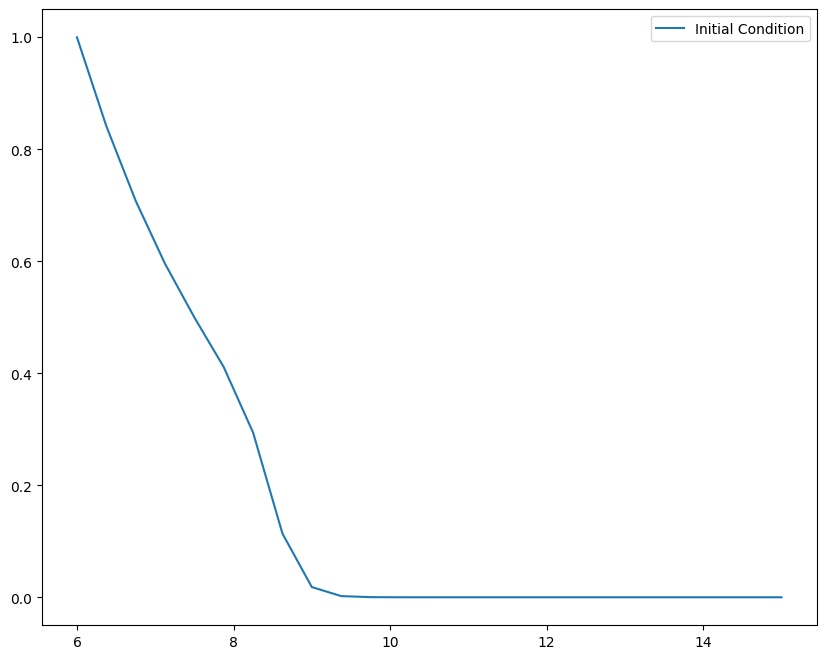

In [ ]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

target_data_o = double_power_law(10**ln_mbh_grid, *params)


target_data, pmin, pmax = forward_scale(target_data_o)



plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, target_data , label="Initial Condition")
plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [6]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
initial_parameters = np.abs(np.random.randn(16))

# bounds = tuple([(0.001, 15) for _ in range(16)])  # 9 for gaussians, 7 for physical params

# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])

result = ray.get(
    objective_function.optimizer.remote(
        bounds=bounds,
        target_data=target_data
    )
)

print("Optimized Parameters:", result)

(ParametersRecovery pid=453478) Starting optimization ...
(ParametersRecovery pid=453478) Objective value: 127.33536917826108 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 121.7823266852303 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 108.87599768903338 Context: Minimum detected in annealing process


(ParametersRecovery pid=453478) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=453478)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=453478) Objective value: 100.52981508100417 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 89.68707093015509 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 89.55842401520954 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 89.55830387708922 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 89.55151812607053 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 89.36507506882928 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 88.6723544383786 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 88.59461870146835 Context: Minimum detected in annealing process
(ParametersRecovery pid=453478) Objective value: 87.278310854652 Context: Minimum detect

In [8]:
result.x
print(f"Parameters:\n\n [\n{"".join(map(lambda x: f"\t{x},\n", result.x))}]")

Parameters:

 [
	0.0018050499388300393,
	0.0002982600772085108,
	0.09973067883508391,
	6.175536058488236,
	6.551014999326979,
	11.141112400495976,
	0.06396270232752495,
	0.11205717860704055,
	0.015178794457753667,
	3.312832803367821,
	2.124405975334356,
	0.5874496830265912,
	0.4996244238814239,
	0.5211046186098843,
	0.48380745198956887,
	0.015259459065226594,
]


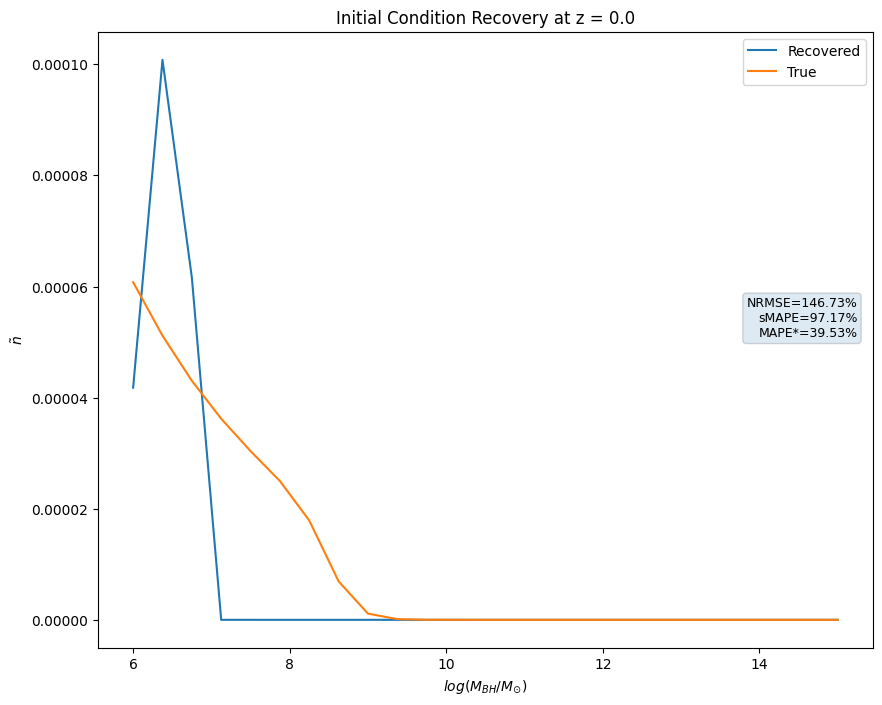

In [11]:
best_params = result.x
best_fun = result.fun


MODEL_PARAM_COUNT = 7
gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]
model_parameters = best_params[-MODEL_PARAM_COUNT:]
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*1000
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

initial_condition_recovered = gaussian_sum_from_p(
        gaussian_parameters,
        ln_mbh_grid,
        n_gauss=3
    )

# métricas robustas
nrmse = nrmse_percent(target_data, initial_condition_recovered, denom='mean')
s_mape = smape_percent(target_data, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition_recovered, label="Recovered")
plt.plot(ln_mbh_grid, target_data, label="True")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.title(f"Initial Condition Recovery at z = {grid_params.z_f}")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

In [10]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

# Build physical model parameters
accretion_params = ParameterAccretionRate(
    # Bloco 2 -- Parametros da Luminosidade
    mbh_par=model_parameters[-MODEL_PARAM_COUNT] * 1e11,
    tau_par=model_parameters[-MODEL_PARAM_COUNT+1] * 1e9,
    alpha_par=model_parameters[-MODEL_PARAM_COUNT+2],

    # Bloco 3 -- Parametros da eficiencia Radiativa
    eta=model_parameters[-MODEL_PARAM_COUNT+3],
    t_q=model_parameters[-MODEL_PARAM_COUNT+4] * 1e9,
    b_1=model_parameters[-MODEL_PARAM_COUNT+5],
    b_2=model_parameters[-MODEL_PARAM_COUNT+6]
)

# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, outputs.n_final, label="Present Recovered")
plt.plot(ln_mbh_grid,target_data, label=f"Target Data (with noise {noise_level*100:.1f}%)")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.yscale("log")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
plt.legend()
plt.show()
plt.close()

NameError: name 'initial_condition' is not defined

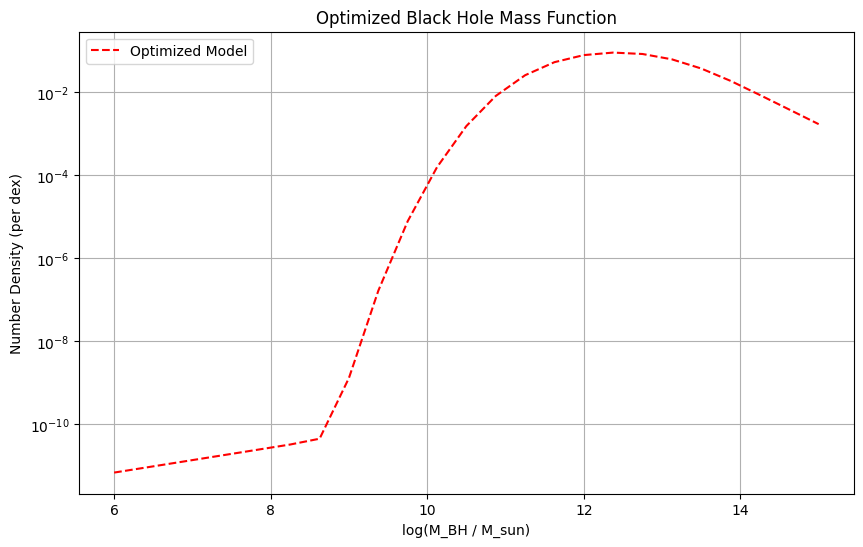

In [ ]:
# === FIGURA 1 ===
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    label='Optimized Model',
    color='red',
    linestyle='--'
)
ax1.set_yscale('log')
ax1.set_xlabel('log(M_BH / M_sun)')
ax1.set_ylabel('Number Density (per dex)')
ax1.set_title('Optimized Black Hole Mass Function')
ax1.legend()
ax1.grid(True)



Metrics for Initial Condition Comparison:
NRMSE=15.47%
sMAPE=49.08%
MAPE*=29.45%
Metrics for Present Data Comparison:
NRMSE=12.60%
sMAPE=18.06%
MAPE*=16.84%


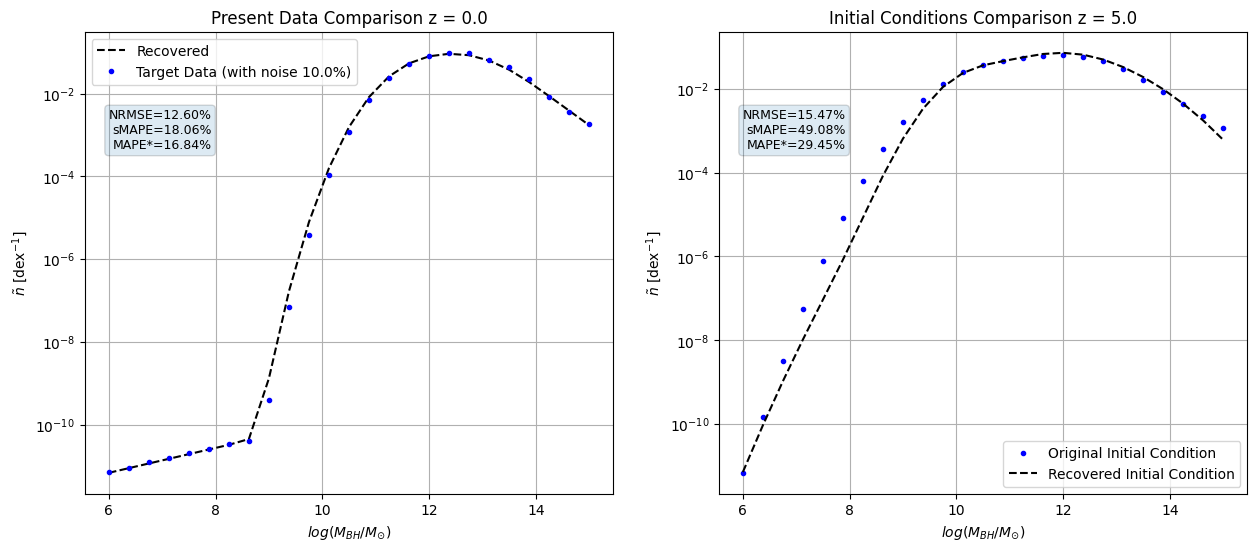

In [ ]:

# === FIGURA 2 ===
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition,
    '.',
    label='Original Initial Condition',
    color='blue'
)
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition_recovered,
    '--',
    label='Recovered Initial Condition',
    color='black',
)

# métricas robustas
nrmse = nrmse_percent(initial_condition, initial_condition_recovered, denom='mean')
s_mape = smape_percent(initial_condition, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(initial_condition, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Initial Condition Comparison:")
print(metrics_text)

ax2.set_yscale('log')
ax2.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax2.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')

ax2.text(0.24, 0.74, metrics_text, transform=ax2.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax2.set_title(f'Initial Conditions Comparison z = {grid_params.z_i}')
ax2.legend()
ax2.grid(True)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Present Data Comparison:")
print(metrics_text)

ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    '--',
    label="Recovered",
    color='black'
)

ax1.plot(
    outputs.ln_mbh_grid,
    target_data,
    '.',
    label=f"Target Data (with noise {noise_level*100:.1f}%)",
    color='blue',
)

ax1.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax1.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')
ax1.set_yscale('log')
ax1.text(0.24, 0.74, metrics_text, transform=ax1.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax1.set_title(f'Present Data Comparison z = {grid_params.z_f}')
ax1.legend()
ax1.grid(True)

plt.show()

In [ ]:
def generate_target_data(noise_level=0.1):
    parameters_observational = np.array([
            3.3e-02,
            8.2e-03,
            5.4e-02,
            1.07e+01,
            1.29e+01,
            1.21e+01,
            6.93e-01,
            1.05e+00,
            7.47e-01
        ])

    mbh_steps = 25

    grid_params = GridParameters(
        mbh_steps=mbh_steps,
        z_steps=mbh_steps*100
    )

    ln_mbh_grid = np.linspace(
        grid_params.mbh_i,
        grid_params.mbh_f,
        grid_params.mbh_steps
    )

    initial_condition = gaussian_sum_from_p(
            parameters_observational,
            ln_mbh_grid,
            n_gauss=3
        )
    objective_function = ParametersRecoveryRemote.remote(
        grid_params=grid_params)

    accretion_params = ParameterAccretionRate(
        mbh_par=2e11,
        alpha_par=3e-1,
        tau_par=5e9,
        eta=0.1,
        t_q=1e9,
        b_1=0.1,
        b_2=0.1,
    )


    # ---- Generate target data ----

    outputs = ray.get(
        objective_function.directly_problem.remote(
            initial_condition,
            accretion_params
        )
    )

    target_data = add_noise_to_data(
        data=outputs.n_final,
        mu=0.0,
        sigma=noise_level,
        rho=0.5,
        alpha=0.5,
        seed=52,
        noise_type='mixed'
    )
    return target_data, initial_condition, ln_mbh_grid, grid_params


params =  {    

    "0.01": [
        5.09e-2, 3.78e-2, 1.03e-2,
        1.22e1, 1.08e1, 1.29e1,
        6.82e-1, 7.12e-1, 9.98e-1,
        4.90e0, 7.34e0, 2.99e-1,
        2.59e-1, 2.34e0,
        3.47e-1, 3.22e-2
    ],

    "0.03": [
        8.21e-3, 3.81e-2, 5.40e-2,
        1.29e1, 1.08e1, 1.22e1,
        1.05e0, 6.95e-1, 7.02e-1,
        2.43e0, 5.42e0, 3.02e-1,
        1.94e-2, 4.29e0,
        3.57e-1, 2.17e-1
    ],

    "0.05": [
        3.44e-2, 3.20e-3, 6.06e-2,
        1.07e1, 1.36e1, 1.22e1,
        7.02e-1, 9.85e-1, 7.67e-1,
        4.96e0, 7.41e0, 2.97e-1,
        1.32e-1, 4.13e0,
        3.12e-1, 2.67e-1
    ],

    "0.10": [
        2.11e-2, 4.29e-2, 3.27e-2,
        1.04e1, 1.18e1, 1.23e1,
        5.28e-1, 7.82e-1, 9.47e-1,
        4.88e0, 7.06e0, 3.07e-1,
        1.01e-1, 4.27e0,
        4.63e-1, 4.19e-1
    ]
}

objective_function = ParametersRecoveryRemote.remote(
grid_params=grid_params)

results = {}
for parameter in params.keys():

    target_data, initial_condition, ln_mbh_grid, grid_params = generate_target_data(noise_level=float(parameter))

    initial_condition_recovered =  gaussian_sum_from_p(
        params[parameter][:-MODEL_PARAM_COUNT],
        ln_mbh_grid,
        n_gauss=3
    )

    # Build physical model parameters
    accretion_params = ParameterAccretionRate(
        # Bloco 2 -- Parametros da Luminosidade
        mbh_par=params[parameter][-MODEL_PARAM_COUNT] * 1e11,
        tau_par=params[parameter][-MODEL_PARAM_COUNT+1] * 1e9,
        alpha_par=params[parameter][-MODEL_PARAM_COUNT+2],

        # Bloco 3 -- Parametros da eficiencia Radiativa
        eta=params[parameter][-MODEL_PARAM_COUNT+3],
        t_q=params[parameter][-MODEL_PARAM_COUNT+4] * 1e9,
        b_1=params[parameter][-MODEL_PARAM_COUNT+5],
        b_2=params[parameter][-MODEL_PARAM_COUNT+6]
    )

    # ---- Generate target data ----

    outputs = ray.get(
        objective_function.directly_problem.remote(
            initial_condition,
            accretion_params
        )
    )

    # métricas robustas
    nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
    s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
    stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

    metrics_text = (
        f'NRMSE={nrmse:.2f}%\n'
        f'sMAPE={s_mape:.2f}%\n'
        f'MAPE*={stab_mape:.2f}%'
    )

    results[parameter] = {
        'metrics': metrics_text,
        'initial_condition_recovered': initial_condition_recovered,
        'initial_condition': initial_condition,
        'target_data': target_data,
        'outputs_n_final': outputs.n_final,
        'ln_mbh_grid': ln_mbh_grid,
        'grid_params': grid_params
    }


2025-11-30 09:39:40,959	INFO worker.py:2003 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


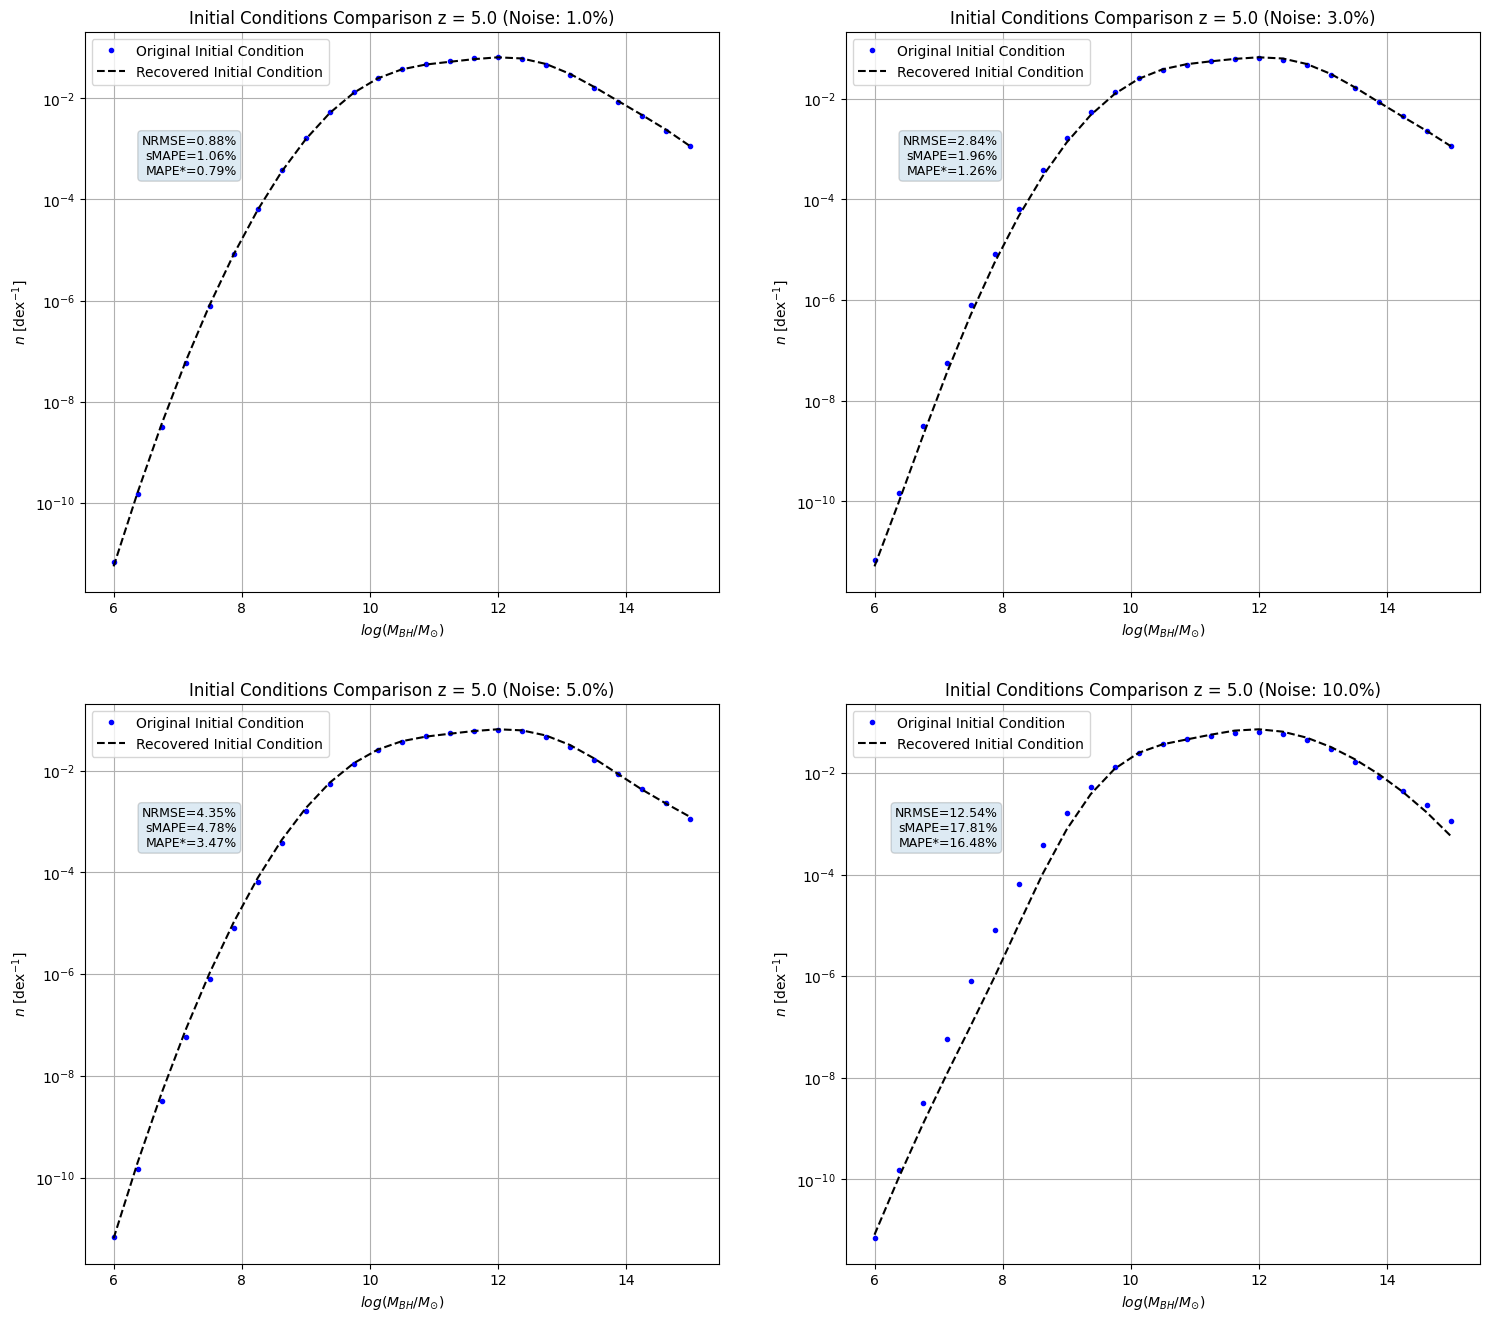

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))


axes = axes.flatten()  


for i, noise in enumerate(results.keys()):
    ax = axes[i]
    res = results[noise]

    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition'],
        '.',
        label='Original Initial Condition',
        color='blue'
    )
    ax.plot(
        res['ln_mbh_grid'],
        res['initial_condition_recovered'],
        '--',
        label='Recovered Initial Condition',
        color='black',
    )

    ax.set_yscale('log')
    ax.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
    ax.set_ylabel(r'$n$ [dex$^{-1}$]')

    ax.text(0.24, 0.74, res['metrics'], transform=ax.transAxes,
                        fontsize=9, va='bottom', ha='right',
                        bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
    ax.set_title(f'Initial Conditions Comparison z = {res["grid_params"].z_i} (Noise: {float(noise)*100:.1f}%)')
    ax.legend()
    ax.grid(True)

plt.show()



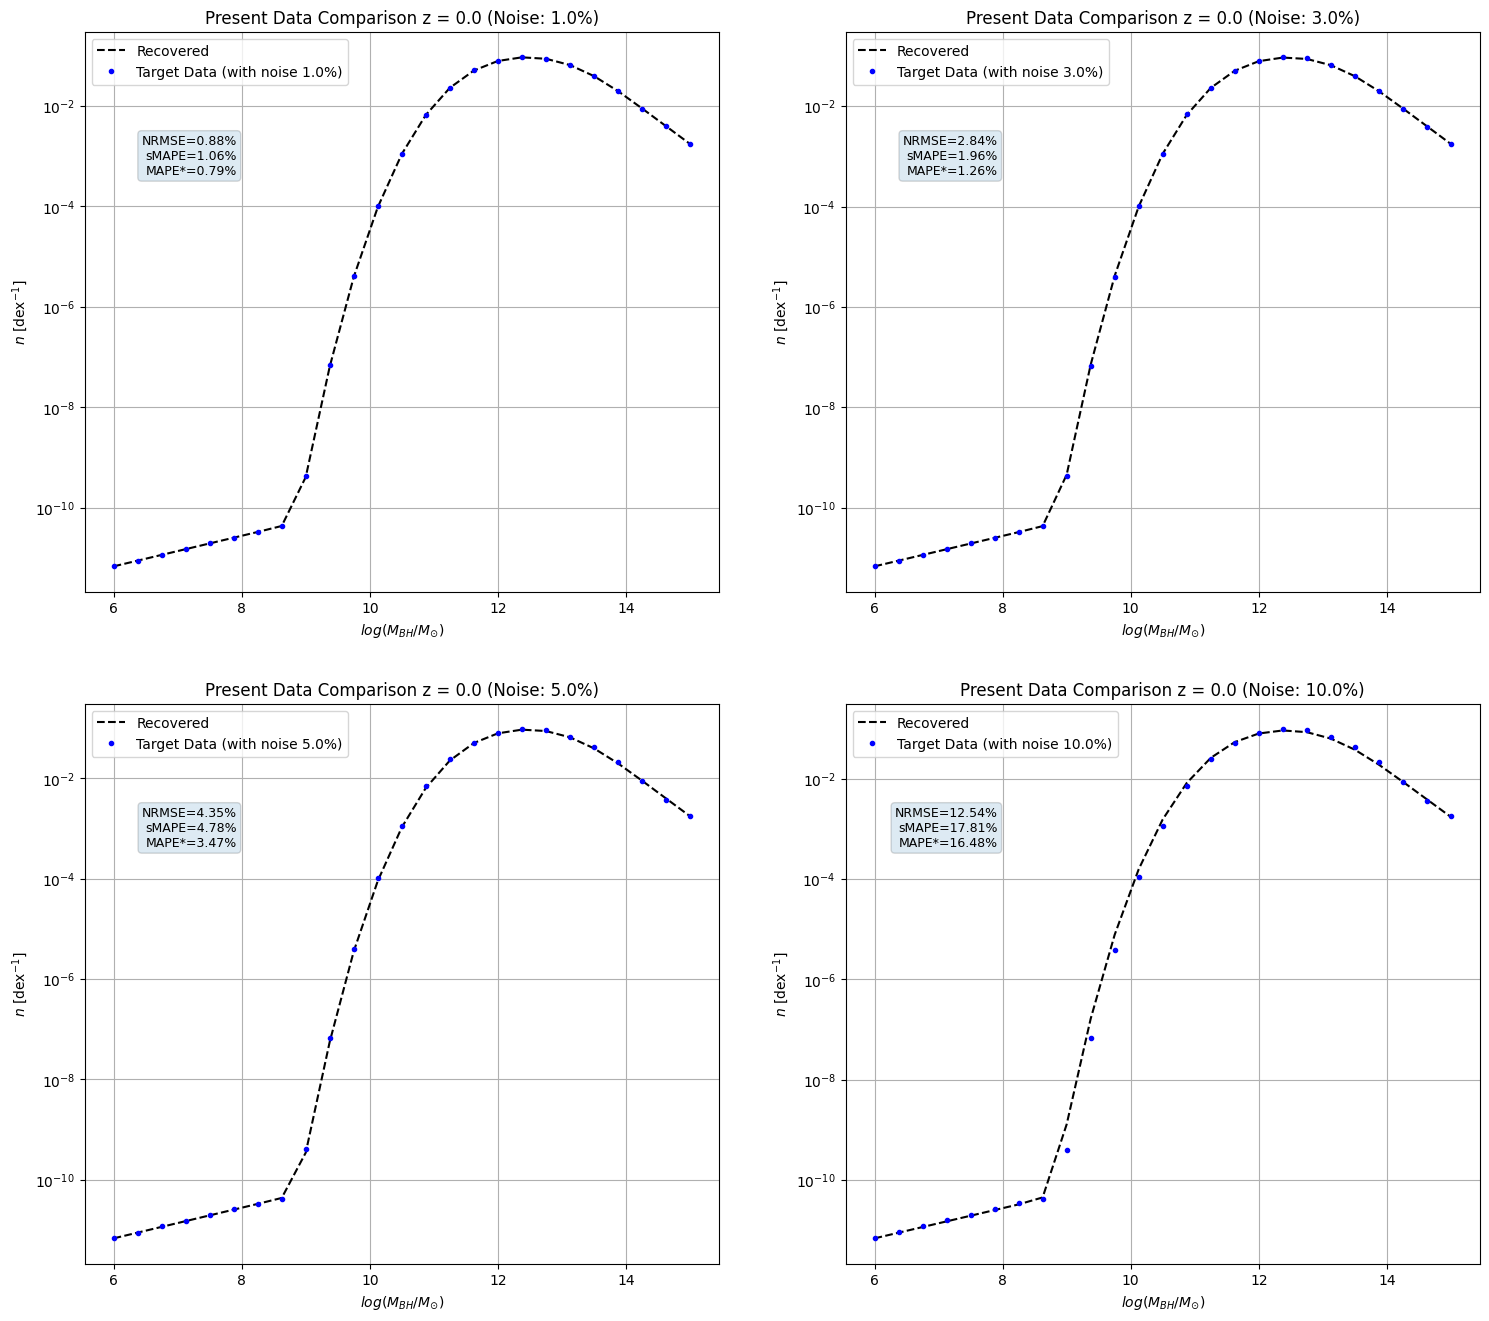

In [ ]:

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 16))
axes2 = axes2.flatten()
for i, noise in enumerate(results.keys()):
    ax2 = axes2[i]
    res = results[noise]

    ax2.plot(
        res['ln_mbh_grid'],
        res['outputs_n_final'],
        '--',
        label="Recovered",
        color='black'
    )

    ax2.plot(
        res['ln_mbh_grid'],
        res['target_data'],
        '.',
        label=f"Target Data (with noise {float(noise)*100:.1f}%)",
        color='blue',
    )

    ax2.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
    ax2.set_ylabel(r'$n$ [dex$^{-1}$]')
    ax2.set_yscale('log')
    ax2.text(0.24, 0.74, res['metrics'], transform=ax2.transAxes,
                        fontsize=9, va='bottom', ha='right',
                        bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
    ax2.set_title(f'Present Data Comparison z = {res["grid_params"].z_f} (Noise: {float(noise)*100:.1f}%)')
    ax2.legend()
    ax2.grid(True)

plt.show()

In [ ]:
ray.shutdown()